In [13]:
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [14]:
from rc import ESN, ESNConfig

In [52]:
pendulum_data = np.load('/Users/iliasoroka/ESN_lyap/s.npy').T

In [70]:
pendulum_data.shape

(2, 500000)

In [54]:
dt = 0.01
dt_orig = 0.001
resample_factor = int(dt / dt_orig)

In [55]:
pendulum_data = pendulum_data[:2, ::resample_factor][:, :]

N: int,
input_dim: int,
spectral_radius: float = 0.9,
alpha: float = 0.000001,
sparsity: float = 0.9,
input_scaling: float = 0.5,
bias_scaling: float = 0.1,
seed: int | None = None,
dtype: Any = lambda : np.dtype(np.float64),
mode: str = "standard",
leaky_rate: float = 0.1,
beta: float = 0.5,
scale: float = 0.1

In [19]:
from rc import ESNConfig


In [25]:
dts = np.linspace(0.01, 0.1, 10)

In [26]:
config = ESNConfig(
    N=700,
    input_dim=2,
    spectral_radius=0.1,
    alpha=9.73476523974807e-07,
    sparsity=0.99,
    input_scaling=1,
    bias_scaling=0.1,
    seed=None,
    mode="leaky",
    leaky_rate=0.06402723031574233,
)

In [81]:
from joblib import Parallel, delayed

def compute_spectrum(dt, i, dt_orig, pendulum_data, config):
    print(f"Computing dt={dt}, iteration={i}")
    resample_factor = int(dt / dt_orig)
    train_data = pendulum_data[:2, ::resample_factor][:, :]
    config_copy = ESNConfig(
        N=config.N,
        input_dim=config.input_dim,
        spectral_radius=config.spectral_radius,
        alpha=config.alpha,
        sparsity=config.sparsity,
        input_scaling=config.input_scaling,
        bias_scaling=config.bias_scaling,
        seed=config.seed,
        mode=config.mode,
        leaky_rate=config.leaky_rate,
    )
    esn = ESN(config_copy)
    esn.train(train_data, washout=1000)
    lyapunov_spectrum = esn.lyapunov_spectrum(train_data,
                                        num_lyaps=40,
                                        steps=20000,
                                        norm_time=2,
                                        dt=dt,
                                        num_samples=5,
                                        warmup=2000,
                                        transient=1000)
    return lyapunov_spectrum

spctrums = []
for dt in dts:
    spectrum_within_dt = Parallel(n_jobs=-2)(
        delayed(compute_spectrum)(dt, i, dt_orig, pendulum_data, config) 
        for i in range(10)
    )
    spctrums.append(spectrum_within_dt)
    print(f"Completed dt={dt}, mean: {spectrum_within_dt[0]['mean']}")
    
    
    

Computing dt=0.01, iteration=1
Computing dt=0.01, iteration=4
Computing dt=0.01, iteration=8
Computing dt=0.01, iteration=0
Computing dt=0.01, iteration=3
Computing dt=0.01, iteration=5
Computing dt=0.01, iteration=7
Computing dt=0.01, iteration=6
Computing dt=0.01, iteration=2
Computing dt=0.01, iteration=9
Completed dt=0.01, mean: [ 0.06101919  0.00640489 -0.01899684 -0.06301272 -5.34400068 -5.72240986
 -5.95955483 -6.10519914 -6.13219868 -6.14547908 -6.16102983 -6.16674314
 -6.17418761 -6.18279168 -6.19622189 -6.20272917 -6.20949829 -6.215072
 -6.21827427 -6.2222466  -6.22549333 -6.23007867 -6.23068362 -6.23356033
 -6.2341955  -6.23784584 -6.2427368  -6.24345342 -6.24732748 -6.24964721
 -6.25036463 -6.25249898 -6.25856867 -6.26275678 -6.26284962 -6.26431106
 -6.26650779 -6.27294093 -6.27481805 -6.27825212]
Computing dt=0.020000000000000004, iteration=1
Computing dt=0.020000000000000004, iteration=0
Computing dt=0.020000000000000004, iteration=4
Computing dt=0.020000000000000004, ite

/opt/homebrew/anaconda3/envs/esn_clean/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Computing dt=0.07, iteration=8
Computing dt=0.07, iteration=9
Completed dt=0.07, mean: [ 5.28517892e-02 -5.26717400e-04 -4.54125780e-02 -9.39794571e-02
 -7.95823260e-01 -8.15747743e-01 -8.21987556e-01 -8.64055960e-01
 -8.68318101e-01 -8.71963225e-01 -8.74747288e-01 -8.75832245e-01
 -8.77214478e-01 -8.77516986e-01 -8.79095270e-01 -8.81204227e-01
 -8.82368080e-01 -8.82935265e-01 -8.83225708e-01 -8.84937448e-01
 -8.86113040e-01 -8.87084791e-01 -8.88031046e-01 -8.88310419e-01
 -8.88994253e-01 -8.89775634e-01 -8.89824807e-01 -8.90712759e-01
 -8.90900436e-01 -8.91126754e-01 -8.91934078e-01 -8.92002542e-01
 -8.92103127e-01 -8.92105814e-01 -8.94018395e-01 -8.94153580e-01
 -8.94163484e-01 -8.94577917e-01 -8.94804654e-01 -8.94948429e-01]
Computing dt=0.08, iteration=5
Computing dt=0.08, iteration=0Computing dt=0.08, iteration=4

Computing dt=0.08, iteration=2
Computing dt=0.08, iteration=6
Computing dt=0.08, iteration=7
Computing dt=0.08, iteration=3
Computing dt=0.08, iteration=1
Computing dt=0

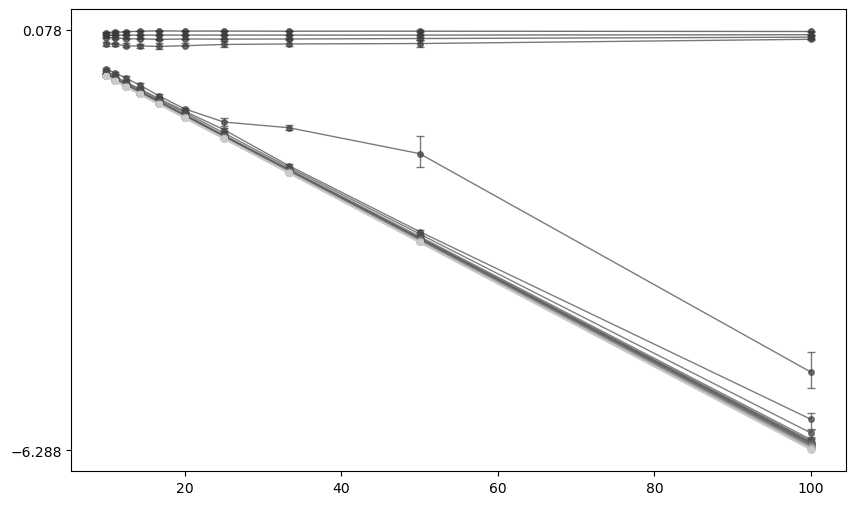

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

num_exponents = len(spctrums[0][0]["mean"])

colors = plt.cm.gray(np.linspace(0.2, 0.8, num_exponents))

def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.median(sample))
    lower = np.percentile(bootstrap_means, (100 - ci) / 2)
    upper = np.percentile(bootstrap_means, 100 - (100 - ci) / 2)
    return lower, upper

for exponent_idx in range(num_exponents):
    inv_dts = [1/dt for dt in dts]
    exponent_values = [
        np.mean([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    exponent_errors_lower = []
    exponent_errors_upper = []
    for spectrum_list in spctrums:
        data = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        lower, upper = bootstrap_ci(data)
        mean_val = np.mean(data)
        exponent_errors_lower.append(abs(mean_val - lower))
        exponent_errors_upper.append(abs(upper - mean_val))
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    ax.errorbar(inv_dts, exponent_values, yerr=exponent_errors, marker='o', markersize=4, linewidth=1, alpha=0.7, capsize=3, color=colors[exponent_idx], label=f'λ_{exponent_idx+1}')


ax.set_yticks([min([min([spectrum["mean"][i] for spectrum in spectrum_list]) for spectrum_list in spctrums for i in range(num_exponents)]), 
               max([max([spectrum["mean"][i] for spectrum in spectrum_list]) for spectrum_list in spctrums for i in range(num_exponents)])])
ax.minorticks_off()


plt.show()


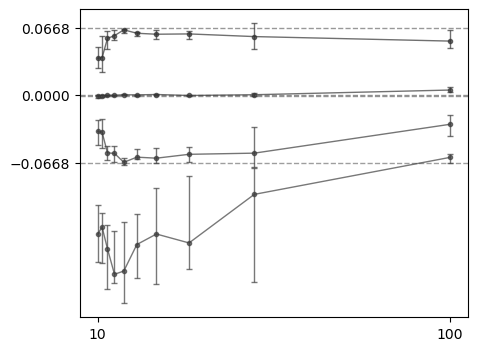

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

for exponent_idx in range(4):
    inv_dts = [1/dt for dt in dts]
    exponent_values = [
        np.median([spectrum["mean"][exponent_idx] for spectrum in spectrum_list])
        for spectrum_list in spctrums
    ]
    exponent_errors_lower = []
    exponent_errors_upper = []
    for spectrum_list in spctrums:
        data = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        lower, upper = bootstrap_ci(data)
        # Use the real mean from the data
        mean_val = np.median(data)
        exponent_errors_lower.append(mean_val - lower)
        exponent_errors_upper.append(upper - mean_val)
    
    exponent_errors = [exponent_errors_lower, exponent_errors_upper]
    ax.errorbar(inv_dts, exponent_values, yerr=exponent_errors, marker='o', markersize=3, linewidth=1, alpha=0.7, capsize=2, color=colors[exponent_idx])

real_lyapunov = [0.06679198, 0.00059611, -0.00055851, -0.06684586]
for exponent_idx in range(4):
    ax.axhline(y=real_lyapunov[exponent_idx], linestyle='--', linewidth=1, alpha=0.5, color=colors[exponent_idx])

ax.set_xticks([min(inv_dts), max(inv_dts)])
ax.set_yticks([real_lyapunov[-1], 0, real_lyapunov[0]])
ax.minorticks_off()
plt.show()


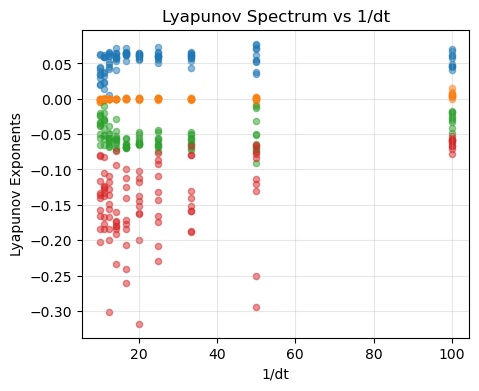

In [ ]:
plt.figure(figsize=(5, 4))

colors = ['C0', 'C1', 'C2', 'C3']

for exponent_idx in range(4):
    inv_dts = [1/dt for dt in dts]
    color = colors[exponent_idx]
    for dt_idx, spectrum_list in enumerate(spctrums):
        inv_dt = inv_dts[dt_idx]
        exponent_values = [spectrum["mean"][exponent_idx] for spectrum in spectrum_list]
        plt.scatter([inv_dt] * len(exponent_values), exponent_values, s=20, alpha=0.5, color=color)

plt.xlabel('1/dt')
plt.ylabel('Lyapunov Exponents')
plt.title('Lyapunov Spectrum vs 1/dt')
plt.grid(True, alpha=0.3)
plt.show()


In [57]:
config = ESNConfig(
    N=700,
    input_dim=2,
    spectral_radius=0.1,
    alpha=9.73476523974807e-07,
    sparsity=0.99,
    input_scaling=1,
    bias_scaling=0.1,
    seed=None,
    mode="leaky",
    leaky_rate=0.06402723031574233,
)

In [58]:
esn = ESN(config)

In [59]:
esn.train(pendulum_data[:2, :], washout=1000)

In [60]:
warmup_data = pendulum_data[:2, 12000:17000]
predictions, states = esn.predict(warmup_data, steps=10000)

In [61]:
predictions.shape

(2, 10000)

In [62]:
import matplotlib.pyplot as plt

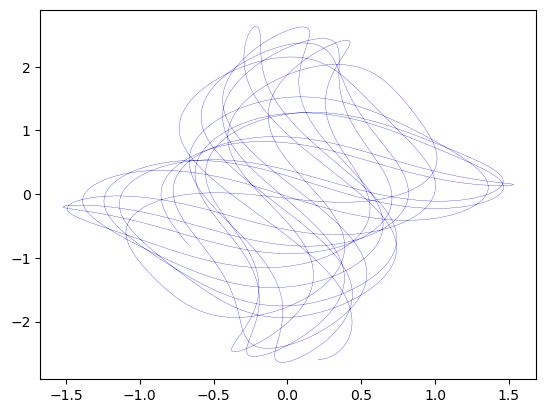

In [63]:
# plt.plot(pendulum_data[0, :], pendulum_data[1, :], 'r', linewidth=0.2)
plt.plot(predictions[0, :], predictions[1, :], 'b', linewidth=0.2)

In [64]:
lyapunov_spectrum = esn.lyapunov_spectrum(pendulum_data[:2, :],
                                          num_lyaps=40,
                                          steps=15000,
                                          norm_time=2,
                                          dt=0.01,
                                          num_samples=2,
                                          warmup=2000,
                                          transient=1000)

In [65]:
lyapunov_spectrum

{'mean': array([ 5.58170532e-02, -6.27014029e-03, -2.22499263e-02, -6.48265926e-02,
        -5.52480946e+00, -5.61809741e+00, -5.85011409e+00, -6.03338974e+00,
        -6.08724960e+00, -6.17943322e+00, -6.19315139e+00, -6.19731645e+00,
        -6.19993943e+00, -6.20573946e+00, -6.20804949e+00, -6.21397743e+00,
        -6.21934778e+00, -6.23001407e+00, -6.23361570e+00, -6.23746659e+00,
        -6.24008906e+00, -6.24240914e+00, -6.24401261e+00, -6.24484934e+00,
        -6.25149924e+00, -6.25253214e+00, -6.25667507e+00, -6.26178037e+00,
        -6.26432147e+00, -6.26808603e+00, -6.27021151e+00, -6.27241833e+00,
        -6.27292403e+00, -6.27460854e+00, -6.27615787e+00, -6.27797890e+00,
        -6.28284827e+00, -6.28348446e+00, -6.28403715e+00, -6.28708240e+00]),
 'std': array([1.77026345e-02, 3.26856413e-03, 5.11010710e-03, 9.25424432e-03,
        1.09286043e-02, 4.55594660e-03, 5.02393286e-02, 2.02902438e-02,
        2.32022250e-02, 7.01873642e-05, 5.70743206e-03, 4.09525465e-03,
       

In [47]:
conditional_lyapunov_spectrum = esn.conditional_lyapunov_spectrum(pendulum_data[:2, 5000:15000],
                                                        num_lyaps=40,
                                                        norm_time=1,
                                                        dt=0.01)

In [66]:
lyapunov_spectrum["mean"]

array([ 5.58170532e-02, -6.27014029e-03, -2.22499263e-02, -6.48265926e-02,
       -5.52480946e+00, -5.61809741e+00, -5.85011409e+00, -6.03338974e+00,
       -6.08724960e+00, -6.17943322e+00, -6.19315139e+00, -6.19731645e+00,
       -6.19993943e+00, -6.20573946e+00, -6.20804949e+00, -6.21397743e+00,
       -6.21934778e+00, -6.23001407e+00, -6.23361570e+00, -6.23746659e+00,
       -6.24008906e+00, -6.24240914e+00, -6.24401261e+00, -6.24484934e+00,
       -6.25149924e+00, -6.25253214e+00, -6.25667507e+00, -6.26178037e+00,
       -6.26432147e+00, -6.26808603e+00, -6.27021151e+00, -6.27241833e+00,
       -6.27292403e+00, -6.27460854e+00, -6.27615787e+00, -6.27797890e+00,
       -6.28284827e+00, -6.28348446e+00, -6.28403715e+00, -6.28708240e+00])

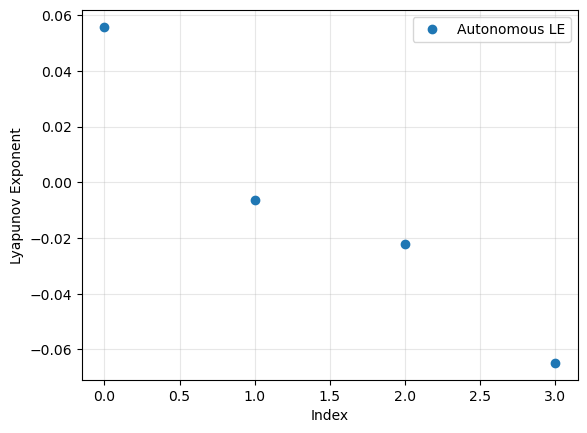

In [69]:
# plt.plot(conditional_lyapunov_spectrum["exponents"], 'o', label='Conditional LE')
plt.plot(lyapunov_spectrum["mean"][:4], 'o', label='Autonomous LE')
plt.xlabel('Index')
plt.ylabel('Lyapunov Exponent')
plt.legend()
plt.grid(True, alpha=0.3)

In [51]:
lyapunov_spectrum["convergence"][0][10000, 0]

IndexError: list index out of range

In [50]:
plt.plot(lyapunov_spectrum["convergence"][0][:, 0])

IndexError: list index out of range

In [22]:
lyapunov_spectrum

{'mean': array([ 5.80034441e-02, -3.40274175e-05, -6.14403198e-02, -1.13908308e-01,
        -5.47890755e-01, -5.58096058e-01, -5.91446135e-01, -5.98095331e-01,
        -6.06420866e-01, -6.10597358e-01, -6.13299118e-01, -6.13444268e-01,
        -6.13917630e-01, -6.14557768e-01, -6.15090183e-01, -6.15469918e-01,
        -6.15633712e-01, -6.15836503e-01, -6.16623190e-01, -6.16835877e-01,
        -6.17203849e-01, -6.17350093e-01, -6.17399817e-01, -6.17927938e-01,
        -6.17968680e-01, -6.18220745e-01, -6.18516127e-01, -6.18922413e-01,
        -6.18988757e-01, -6.19026704e-01, -6.19176346e-01, -6.19444430e-01,
        -6.19535128e-01, -6.19811573e-01, -6.19825019e-01, -6.19863103e-01,
        -6.20045440e-01, -6.20133616e-01, -6.20334765e-01, -6.20739417e-01]),
 'std': array([3.41348030e-03, 2.98985998e-03, 1.02062939e-02, 3.29252501e-03,
        3.03936334e-03, 2.25143419e-03, 1.95616309e-03, 3.31919542e-03,
        9.74306426e-04, 2.19726220e-03, 9.42141529e-04, 9.89586046e-04,
       

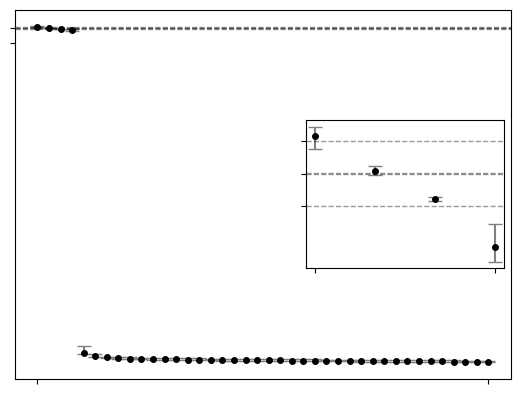

In [ ]:
plt.figure()

all_samples = filtered_exp
median_lyapunov = np.median(all_samples, axis=0)

n_bootstraps = 1000
bootstrap_medians = []
for _ in range(n_bootstraps):
    resample_idxs = np.random.choice(len(all_samples), len(all_samples), replace=True)
    resample = all_samples[resample_idxs]
    bootstrap_medians.append(np.median(resample, axis=0))

bootstrap_medians = np.array(bootstrap_medians)
ci_lower = np.percentile(bootstrap_medians, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_medians, 97.5, axis=0)
yerr = np.array([median_lyapunov - ci_lower, ci_upper - median_lyapunov])

img = plt.errorbar(range(1, len(median_lyapunov) + 1), median_lyapunov,
                   yerr=yerr, fmt='k.', ms=8, capsize=5, 
                   ecolor='gray')

plt.xticks([1, len(median_lyapunov)], ['', ''])
plt.yticks([0, -1], ['', ''])
plt.minorticks_off()

real_lyapunov = [0.06679198, 0.00059611, -0.00055851, -0.06684586]  
for idx, lyap_val in enumerate(real_lyapunov):
    plt.axhline(y=lyap_val, color='k', linestyle='--', 
                linewidth=1, alpha=0.4)

axins = inset_axes(plt.gca(), width="40%", height="40%", loc='center right')

yerr_inset = np.array([median_lyapunov[:4] - ci_lower[:4], 
                       ci_upper[:4] - median_lyapunov[:4]])
axins.errorbar(range(1, 5), median_lyapunov[:4], yerr=yerr_inset, 
               fmt='k.', ms=8, capsize=5, ecolor='gray')

for idx, lyap_val in enumerate(real_lyapunov):
    axins.axhline(y=lyap_val, color='k', linestyle='--', 
                  linewidth=1, alpha=0.4)

axins.set_xticks([1, 4], ['', ''])
axins.set_yticklabels([])
axins.tick_params(labelsize=18)
axins.set_yticks([real_lyapunov[-1], 0, real_lyapunov[0]])  
axins.minorticks_off()

plt.savefig('lyapunov_exponents.png', bbox_inches='tight', dpi=700, transparent=True)
plt.show()

In [7]:
from rc import ESNSearchSpaceBuilder, EvaluationConfig, optimize_esn

In [20]:
space = (ESNSearchSpaceBuilder()
    .optimize("spectral_radius", bounds=(0.01, 2))  
    .optimize("alpha")
    .optimize("input_scaling", bounds=(0.01, 3))
    .optimize("bias_scaling", bounds=(0.01, 2))
    .optimize("leaky_rate", bounds=(0.01, 1))
    .optimize("scale", bounds=(0.01, 0.2))
    .fix(N=500, mode="leakyrand", sparsity=0.99)
    .build())

In [27]:
config_eval = EvaluationConfig(
    washout=2000,
    warmup_steps=1000,
    predict_steps=4500,
    n_predictions=3,   # predictions per RC instance
    n_instances=5,     # RC instances per trial 
    metrics=['wasserstein'],
    wasserstein_projections=150,
    clip_wasserstein=3,
    constrain_cle=True,
    cle_threshold=-10,
    dt=dt,
    length=10000
    )

In [28]:
from sklearn.preprocessing import StandardScaler
data_norm = StandardScaler().fit_transform(pendulum_data.T).T

In [29]:
import warnings
import logging

logging.getLogger('ax').setLevel(logging.ERROR)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='botorch')
warnings.filterwarnings('ignore', module='gpytorch')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='linear_operator')

best_params, best_params_overall, ax_client = optimize_esn(data = data_norm[:, :10000], space = space, config = config_eval, n_trials = 30)

[INFO 02-02 00:18:16] ax.generation_strategy.dispatch_utils: Using Generators.BOTORCH_MODULAR since there is at least one ordered parameter and there are no unordered categorical parameters.
[INFO 02-02 00:18:16] ax.generation_strategy.dispatch_utils: Using Bayesian Optimization generation strategy: GenerationStrategy(name='Sobol+BoTorch', steps=[Sobol for 12 trials, BoTorch for subsequent trials]). Iterations after 12 will take longer to generate due to model-fitting.


{'spectral_radius': 1.4805697160959244, 'alpha': 7.834899535332279e-06, 'input_scaling': 1.9825997018814088, 'bias_scaling': 1.5786884886026382, 'leaky_rate': 0.1899674916267395, 'scale': 0.10406433254480361}
{'wasserstein': (np.float64(2.732331259267423), np.float64(0.55637816099114)), 'max_cle': (np.float64(-6.956675128657668), np.float64(0.13325355624225646))}
{'spectral_radius': 0.7088020747341216, 'alpha': 0.00014511646927142503, 'input_scaling': 0.8242481989506633, 'bias_scaling': 0.10657007831148803, 'leaky_rate': 0.9215207844227552, 'scale': 0.13186846406199038}
{'wasserstein': (np.float64(2.8726141171612105), np.float64(0.47148389942501306)), 'max_cle': (np.float64(-58.63946362110063), np.float64(1.209965754803479))}
{'spectral_radius': 0.10093625877052545, 'alpha': 2.7202559383909194e-07, 'input_scaling': 2.728566217711195, 'bias_scaling': 1.3628758998401462, 'leaky_rate': 0.6476302758697421, 'scale': 0.18516952170059087}
{'wasserstein': (np.float64(3.0), np.float64(0.0719189

In [33]:
best_params

{'spectral_radius': 0.8543101953695833,
 'alpha': 0.002857536507578156,
 'input_scaling': 2.4125331659065377,
 'bias_scaling': 2.0,
 'leaky_rate': 0.29772092993060484,
 'scale': 0.2}

In [34]:
best_params_overall

In [32]:
final_config = space.build_config(best_params, input_dim=data_norm.shape[0])

In [35]:
esn = ESN(final_config)

In [36]:
esn.train(data_norm[:, :10000], washout=1000)
predictions, states = esn.predict(data_norm[:, 10000:], steps=10000)
predictions.shape

(2, 10000)

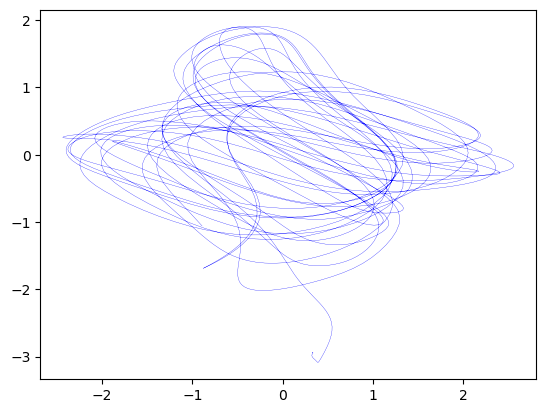

In [37]:
import matplotlib.pyplot as plt
plt.plot(predictions[0, :], predictions[1, :], 'b', linewidth=0.2)
# plt.plot(pendulum_data[0, 10000:], pendulum_data[1, 10000:], 'r', linewidth=0.2)
plt.show()

In [40]:
spectrum = esn.lyapunov_spectrum(data_norm[:, 10000:], 10, 7500, 1, dt, 1, 1000, 1000, False)

In [41]:
spectrum

{'mean': array([-5.14690653e-03, -1.55044661e+00, -1.55454590e+00, -2.97989910e+00,
        -9.33046133e+00, -1.00552872e+01, -1.01250159e+01, -1.01417719e+01,
        -1.04520839e+01, -1.05020259e+01]),
 'std': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'all_samples': array([[-5.14690653e-03, -1.55454590e+00, -1.55044661e+00,
         -2.97989910e+00, -9.33046133e+00, -1.00552872e+01,
         -1.01250159e+01, -1.01417719e+01, -1.04520839e+01,
         -1.05020259e+01]]),
 'convergence': [],
 'num_valid_samples': 1,
 'max_lyapunov': np.float64(-0.005146906532309467),
 'distances': [np.float64(0.8236105719088009)]}